Text length: 10,000 chars
Unique chars: 57
Sequences: (5000, 30), Labels: (5000,)

Training: LSTM
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.1408 - loss: 3.3957
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.2372 - loss: 2.8591
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.2850 - loss: 2.5269
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.3440 - loss: 2.3175
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.3843 - loss: 2.1671

Training: Transformer + PE
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1357 - loss: 3.4515
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1541 - loss: 3.2163
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1541 - loss: 3.2085
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.1616 - loss: 3.1715
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.2535 - loss: 2.7406


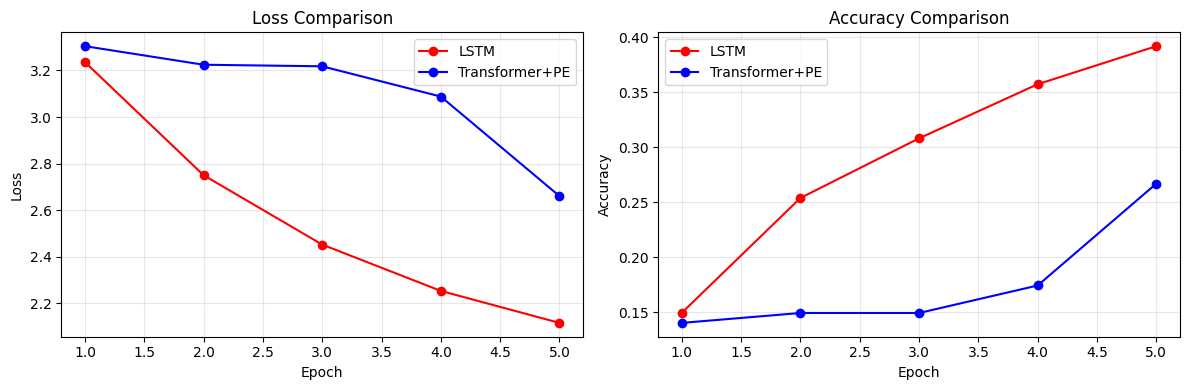

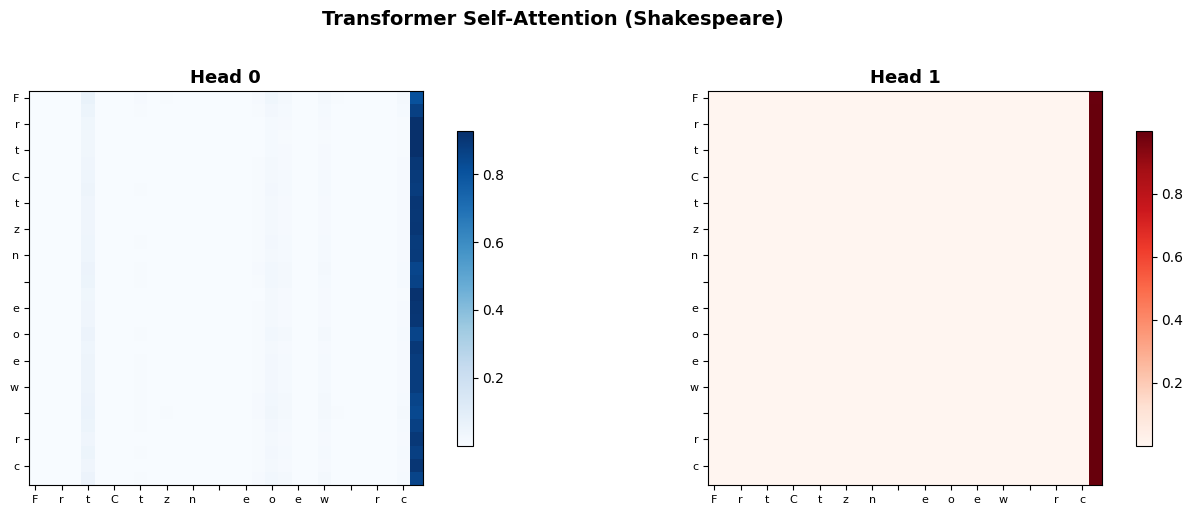


 Temperature = 0.2

[LSTM]
nt the pares heall and the pare and the and tour and the and tour and the porend the berend the pare then sour and tour the and and one there and the pares tour the parens the parend the parers the po

[Transformer+PE]
 ane all ane ane the alll the the are rere aas tor are are anine the arell are ton anar anal alll the ther are alll ane the the ane ane the ane ane re ane alll ane the nal are the are me arel are the 

 Temperature = 0.5

[LSTM]
 tours ar ithere gours of pore to bears at intt ind oud an citizen: as yourt our the santine core wour thes wourss andt pitizen:
Wowy tou mathere and our the pithe fores porest wheat core and enore an

[Transformer+PE]
 al ane no tidit bhe anel mianes one bel
All
Yorirelll amelk yon ale ces peve yos aron cin, be ren ne maey thel inet yort arer the torat thed shes our wee there ell nounl
We. allllssd atiret oor tonrs

 Temperature = 1.0

[LSTM]
r.
Nistle yolving,
Io
Whey ford ameds, s rey igy ode veache theill bove, ica

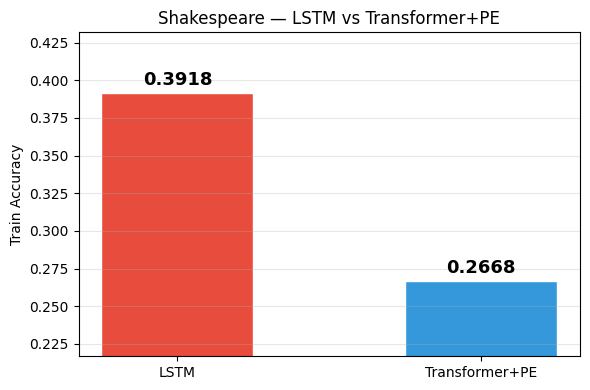

In [1]:
# ========================================================
# Week 15 : LSTM vs Transformer+PE (Shakespeare)
# Character-level Language Model Comparison
# ========================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

tf.random.set_seed(42)
np.random.seed(42)

SEQ_LEN = 30
EMBED_DIM = 64
EPOCHS = 5
BATCH = 32
NUM_SAMPLES = 5000
MAX_TOKENS = 10000

# =========================================
# 1. Load Shakespeare
# =========================================
path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
text = open(path, 'r').read()[:MAX_TOKENS]
print(f"Text length: {len(text):,} chars")

chars = sorted(set(text))
VOCAB_SIZE = len(chars)
print(f"Unique chars: {VOCAB_SIZE}")

char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
encoded = np.array([char_to_idx[c] for c in text])

X, y = [], []
for i in range(len(encoded) - SEQ_LEN):
    X.append(encoded[i:i+SEQ_LEN])
    y.append(encoded[i+SEQ_LEN])
X = np.array(X[:NUM_SAMPLES])
y = np.array(y[:NUM_SAMPLES])
print(f"Sequences: {X.shape}, Labels: {y.shape}")

# =========================================
# 2. Positional Encoding
# =========================================
def get_positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    dim = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (dim // 2)) / d_model)
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)

# =========================================
# 3. Model Definitions
# =========================================

# --- LSTM ---
model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dense(VOCAB_SIZE, activation='softmax')
])

# --- Transformer + PE ---
class TransformerPE(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.pe = get_positional_encoding(SEQ_LEN, EMBED_DIM)
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=EMBED_DIM)
        self.norm = tf.keras.layers.LayerNormalization()
        self.gap = tf.keras.layers.GlobalAveragePooling1D()
        self.dense = tf.keras.layers.Dense(VOCAB_SIZE, activation='softmax')

    def call(self, x, return_attention=False):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x) + self.pe[:, :seq_len, :]
        attn_out, attn_scores = self.mha(x, x, x, return_attention_scores=True)
        x = self.norm(x + attn_out)
        x = self.gap(x)
        logits = self.dense(x)
        return (logits, attn_scores) if return_attention else logits

model_tf = TransformerPE()

model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# =========================================
# 4. Train Both
# =========================================
print("\n" + "=" * 50)
print("Training: LSTM")
print("=" * 50)
h_lstm = model_lstm.fit(X, y, epochs=EPOCHS, batch_size=BATCH, verbose=1)

print("\n" + "=" * 50)
print("Training: Transformer + PE")
print("=" * 50)
h_tf = model_tf.fit(X, y, epochs=EPOCHS, batch_size=BATCH, verbose=1)

# --- Loss & Accuracy Comparison ---
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, EPOCHS + 1)
a1.plot(ep, h_lstm.history['loss'], 'r-o', label='LSTM')
a1.plot(ep, h_tf.history['loss'], 'b-o', label='Transformer+PE')
a1.set(title='Loss Comparison', xlabel='Epoch', ylabel='Loss'); a1.legend(); a1.grid(True, alpha=.3)
a2.plot(ep, h_lstm.history['accuracy'], 'r-o', label='LSTM')
a2.plot(ep, h_tf.history['accuracy'], 'b-o', label='Transformer+PE')
a2.set(title='Accuracy Comparison', xlabel='Epoch', ylabel='Accuracy'); a2.legend(); a2.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

# =========================================
# 5. Attention Heatmap (Transformer only)
# =========================================
sample = X[:1]
_, attn = model_tf(sample, return_attention=True)
sample_chars = [idx_to_char[i] for i in sample[0]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for head_idx, (ax, cmap, title) in enumerate(
    [(ax1, 'Blues', 'Head 0'), (ax2, 'Reds', 'Head 1')]):
    im = ax.imshow(attn[0, head_idx].numpy(), cmap=cmap)
    step = max(1, len(sample_chars) // 15)
    ticks = range(0, len(sample_chars), step)
    labels = [sample_chars[i] for i in ticks]
    ax.set_xticks(ticks); ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle('Transformer Self-Attention (Shakespeare)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# =========================================
# 6. Temperature Generation — Both Models
# =========================================
def generate_lstm(model, seed, length=200, temperature=1.0):
    result = list(seed)
    input_seq = [char_to_idx[c] for c in seed[-SEQ_LEN:]]
    for _ in range(length):
        x = np.array([input_seq[-SEQ_LEN:]])
        preds = model.predict(x, verbose=0)[0]
        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        next_idx = np.random.choice(len(preds), p=preds)
        result.append(idx_to_char[next_idx])
        input_seq.append(next_idx)
    return ''.join(result[len(seed):])

def generate_tf(model, seed, length=200, temperature=1.0):
    result = list(seed)
    input_seq = [char_to_idx[c] for c in seed[-SEQ_LEN:]]
    for _ in range(length):
        x = np.array([input_seq[-SEQ_LEN:]])
        preds = model(x, return_attention=False).numpy()[0]
        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        next_idx = np.random.choice(len(preds), p=preds)
        result.append(idx_to_char[next_idx])
        input_seq.append(next_idx)
    return ''.join(result[len(seed):])

seed = text[:SEQ_LEN]
temperatures = [0.2, 0.5, 1.0]

for t in temperatures:
    print(f"\n{'='*60}")
    print(f" Temperature = {t}")
    print(f"{'='*60}")
    print(f"\n[LSTM]")
    print(generate_lstm(model_lstm, seed, length=200, temperature=t))
    print(f"\n[Transformer+PE]")
    print(generate_tf(model_tf, seed, length=200, temperature=t))

# =========================================
# 7. Final Comparison
# =========================================
fig, ax = plt.subplots(figsize=(6, 4))
names = ['LSTM', 'Transformer+PE']
accs = [h_lstm.history['accuracy'][-1], h_tf.history['accuracy'][-1]]
bars = ax.bar(names, accs, color=['#e74c3c', '#3498db'], edgecolor='white', width=0.5)
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.4f}',
            ha='center', fontweight='bold', fontsize=13)
ax.set(title='Shakespeare — LSTM vs Transformer+PE', ylabel='Train Accuracy')
ax.set_ylim(min(accs) - 0.05, max(accs) + 0.04)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()